In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [17]:
df = pd.read_csv("train.csv")
print(f"Loaded real dataset from train.csv: {df.shape}")


df.head()

Loaded real dataset from train.csv: (30000, 24)


,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),...,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD)
0,C-36995,Frederica Shealy,F,56,1933.05,Low,Working,Sales staff,Semi-Urban,72809.58,...,809.44,0,NaN,746,1933.05,4,Rural,1,119933.46,54607.18
1,C-33999,America Calderone,M,32,4952.91,Low,Working,NaN,Semi-Urban,46837.47,...,780.40,0,Unpossessed,608,4952.91,2,Rural,1,54791.00,37469.98
2,C-3770,Rosetta Verne,F,65,988.19,High,Pensioner,NaN,Semi-Urban,45593.04,...,833.15,0,Unpossessed,546,988.19,2,Urban,0,72440.58,36474.43
3,C-26480,Zoe Chitty,F,65,NaN,High,Pensioner,NaN,Rural,80057.92,...,832.70,1,Unpossessed,890,NaN,2,Semi-Urban,1,121441.51,56040.54
4,C-23459,Afton Venema,F,31,2614.77,Low,Working,High skill tech staff,Semi-Urban,113858.89,...,745.55,1,Active,715,2614.77,4,Semi-Urban,1,208567.91,74008.28


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer ID                  30000 non-null  object 
 1   Name                         30000 non-null  object 
 2   Gender                       29947 non-null  object 
 3   Age                          30000 non-null  int64  
 4   Income (USD)                 25424 non-null  float64
 5   Income Stability             28317 non-null  object 
 6   Profession                   30000 non-null  object 
 7   Type of Employment           22730 non-null  object 
 8   Location                     30000 non-null  object 
 9   Loan Amount Request (USD)    30000 non-null  float64
 10  Current Loan Expenses (USD)  29828 non-null  float64
 11  Expense Type 1               30000 non-null  object 
 12  Expense Type 2               30000 non-null  object 
 13  Dependents      

In [19]:
df.describe()

,Age,Income (USD),Loan Amount Request (USD),Current Loan Expenses (USD),Dependents,Credit Score,No. of Defaults,Property ID,Property Age,Property Type,Co-Applicant,Property Price,Loan Sanction Amount (USD)
count,30000.000000,2.542400e+04,30000.000000,29828.000000,27507.000000,28297.000000,30000.000000,30000.000000,2.515000e+04,30000.000000,30000.000000,3.000000e+04,29660.000000
mean,40.092300,2.630574e+03,88826.333855,400.936876,2.253027,739.885381,0.193933,501.934700,2.631119e+03,2.460067,-4.743867,1.317597e+05,47649.342208
std,16.045129,1.126272e+04,59536.949605,242.545375,0.951162,72.163846,0.395384,288.158086,1.132268e+04,1.118562,74.614593,9.354955e+04,48221.146686
min,18.000000,3.777000e+02,6048.240000,-999.000000,1.000000,580.000000,0.000000,1.000000,3.777000e+02,1.000000,-999.000000,-9.990000e+02,-999.000000
25%,25.000000,1.650457e+03,41177.755000,247.667500,2.000000,681.880000,0.000000,251.000000,1.650450e+03,1.000000,1.000000,6.057216e+04,0.000000
50%,40.000000,2.222435e+03,75128.075000,375.205000,2.000000,739.820000,0.000000,504.000000,2.223250e+03,2.000000,1.000000,1.099936e+05,35209.395000
75%,55.000000,3.090593e+03,119964.605000,521.292500,3.000000,799.120000,0.000000,751.000000,3.091408e+03,3.000000,1.000000,1.788807e+05,74261.250000
max,65.000000,1.777460e+06,621497.820000,3840.880000,14.000000,896.260000,1.000000,999.000000,1.777460e+06,4.000000,1.000000,1.077967e+06,481907.320000


In [20]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values per column:")
missing

Missing values per column:


Type of Employment             7270
Property Age                   4850
Income (USD)                   4576
Dependents                     2493
Credit Score                   1703
Income Stability               1683
Has Active Credit Card         1566
Property Location               356
Loan Sanction Amount (USD)      340
Current Loan Expenses (USD)     172
Gender                           53
dtype: int64

In [21]:
import pandas as pd
from sklearn.impute import SimpleImputer

df_clean = df.copy()

numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df_clean.select_dtypes(include=['object']).columns

num_imputer = SimpleImputer(strategy='median')
df_clean[numeric_cols] = num_imputer.fit_transform(df_clean[numeric_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
df_clean[categorical_cols] = cat_imputer.fit_transform(df_clean[categorical_cols])

print(df_clean.isnull().sum())

df = df_clean

Customer ID                    0
Name                           0
Gender                         0
Age                            0
Income (USD)                   0
Income Stability               0
Profession                     0
Type of Employment             0
Location                       0
Loan Amount Request (USD)      0
Current Loan Expenses (USD)    0
Expense Type 1                 0
Expense Type 2                 0
Dependents                     0
Credit Score                   0
No. of Defaults                0
Has Active Credit Card         0
Property ID                    0
Property Age                   0
Property Type                  0
Property Location              0
Co-Applicant                   0
Property Price                 0
Loan Sanction Amount (USD)     0
dtype: int64


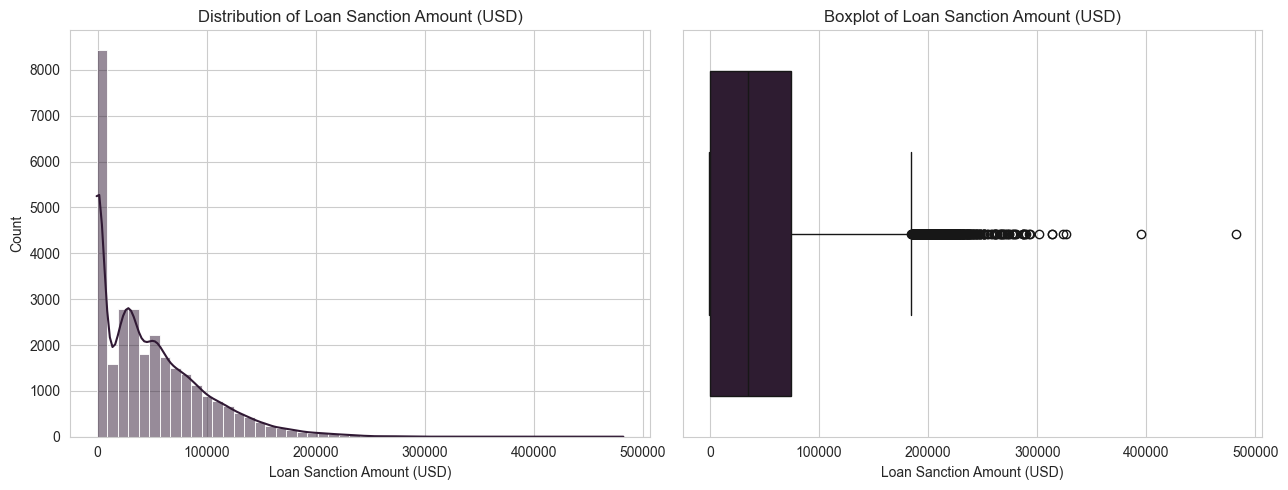

count     30000.000000
mean      47508.356140
std       47965.185159
min        -999.000000
25%           0.000000
50%       35209.395000
75%       73763.532500
max      481907.320000
Name: Loan Sanction Amount (USD), dtype: float64


In [22]:
target_col = "Loan Sanction Amount (USD)"

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df[target_col].dropna(), kde=True, bins=50, ax=axes[0], color="#301934")
axes[0].set_title("Distribution of Loan Sanction Amount (USD)")
axes[0].set_xlabel("Loan Sanction Amount (USD)")

sns.boxplot(x=df[target_col].dropna(), ax=axes[1], color="#301934")
axes[1].set_title("Boxplot of Loan Sanction Amount (USD)")
plt.tight_layout()
plt.show()

print(df[target_col].describe())


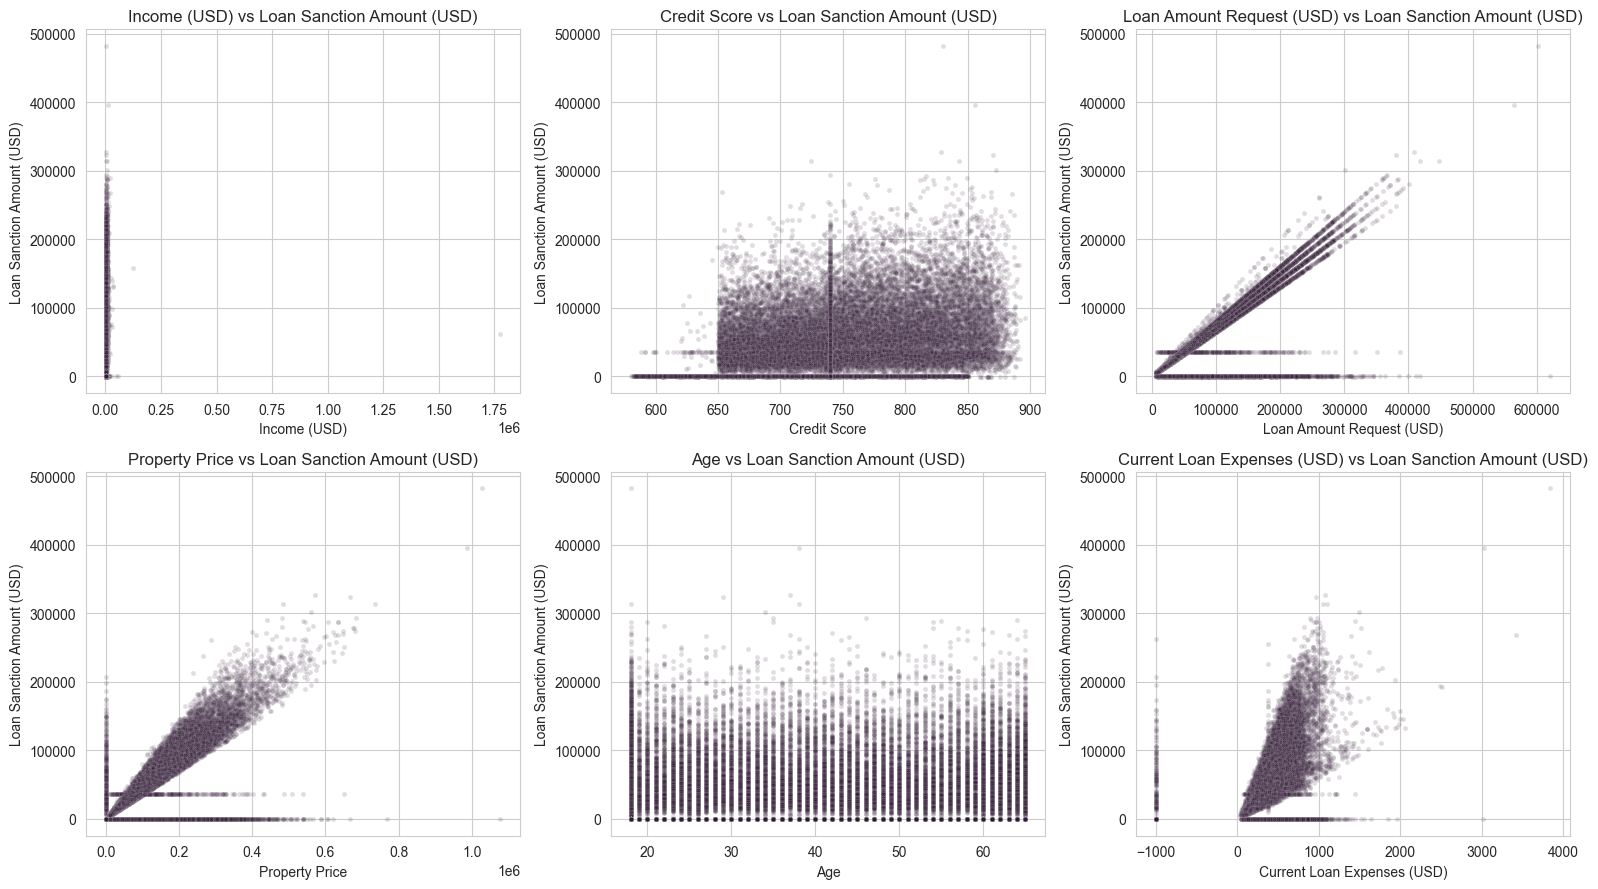

In [23]:
num_features_for_eda = ["Income (USD)", "Credit Score", "Loan Amount Request (USD)",
                         "Property Price", "Age", "Current Loan Expenses (USD)"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()
for i, col in enumerate(num_features_for_eda):
    sns.scatterplot(x=df[col], y=df[target_col], alpha=0.15, ax=axes[i], s=12, color="#301934")
    axes[i].set_title(f"{col} vs {target_col}")
plt.tight_layout()
plt.show()


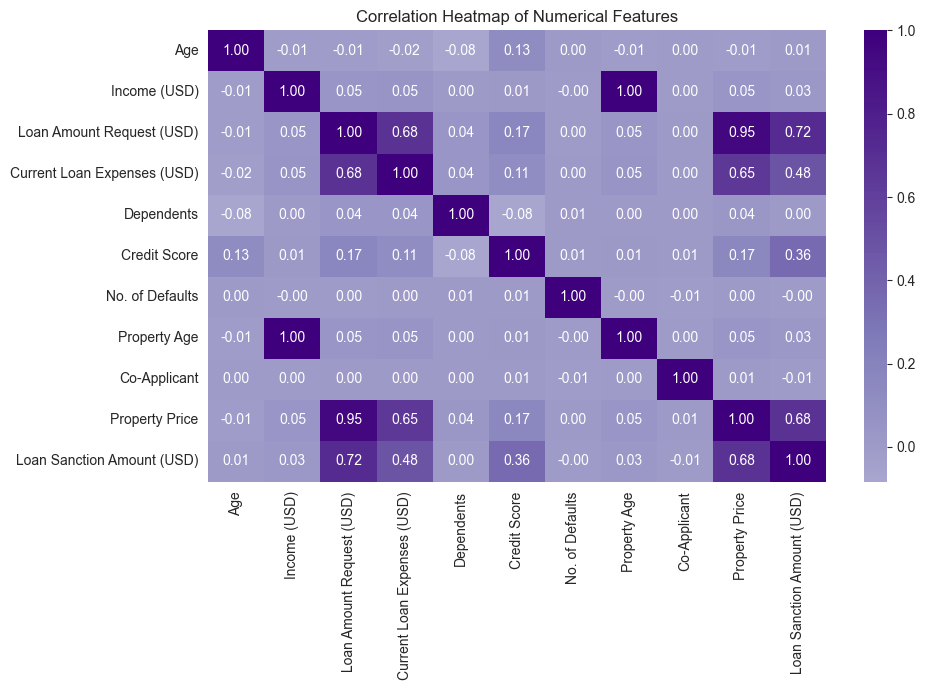

In [24]:
num_cols_corr = ["Age", "Income (USD)", "Loan Amount Request (USD)", "Current Loan Expenses (USD)",
                  "Dependents", "Credit Score", "No. of Defaults", "Property Age",
                  "Co-Applicant", "Property Price", target_col]

plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols_corr].corr(), annot=True, fmt=".2f", cmap="Purples", center=0)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()


In [25]:
X = df.drop(columns=[target_col])
y = df[target_col]

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Numerical features   :", numerical_cols)
print("Categorical features :", categorical_cols)


Numerical features   : ['Age', 'Income (USD)', 'Loan Amount Request (USD)', 'Current Loan Expenses (USD)', 'Dependents', 'Credit Score', 'No. of Defaults', 'Property ID', 'Property Age', 'Property Type', 'Co-Applicant', 'Property Price']
Categorical features : ['Customer ID', 'Name', 'Gender', 'Income Stability', 'Profession', 'Type of Employment', 'Location', 'Expense Type 1', 'Expense Type 2', 'Has Active Credit Card', 'Property Location']


In [26]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (24000, 23), Test shape: (6000, 23)


In [28]:
def build_pipeline(regressor):
    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", regressor)
    ])

def evaluate(model, X_tr, y_tr, X_te, y_te):
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)
    return {
        "train": {
            "MAE": mean_absolute_error(y_tr, y_tr_pred),
            "MSE": mean_squared_error(y_tr, y_tr_pred),
            "RMSE": np.sqrt(mean_squared_error(y_tr, y_tr_pred)),
            "R2": r2_score(y_tr, y_tr_pred),
        },
        "test": {
            "MAE": mean_absolute_error(y_te, y_te_pred),
            "MSE": mean_squared_error(y_te, y_te_pred),
            "RMSE": np.sqrt(mean_squared_error(y_te, y_te_pred)),
            "R2": r2_score(y_te, y_te_pred),
        },
        "y_test_pred": y_te_pred
    }

results = {}
best_params = {}

lin_pipe = build_pipeline(LinearRegression())
start = time.time()
lin_pipe.fit(X_train, y_train)
lin_time = time.time() - start

lin_scores = evaluate(lin_pipe, X_train, y_train, X_test, y_test)
lin_scores["training_time"] = lin_time
results["Linear Regression"] = lin_scores
best_params["Linear Regression"] = {"Search Method": "N/A", "Best Params": "N/A", "Best CV R2": "N/A"}

print(f"Linear Regression trained in {lin_time:.3f}s")
print("Test R2 :", round(lin_scores["test"]["R2"], 4))
print("Test RMSE:", round(lin_scores["test"]["RMSE"], 2))


Linear Regression trained in 0.716s
Test R2 : 0.515
Test RMSE: 33402.74


In [29]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grids = {
    "Ridge Regression": (Ridge(random_state=RANDOM_STATE), {"regressor__alpha": [0.01, 0.1, 1, 10, 100]}),
    "Lasso Regression": (Lasso(random_state=RANDOM_STATE, max_iter=10),
                          {"regressor__alpha": [0.001, 0.01, 0.1, 1, 10]}),
    "Elastic Net Regression": (ElasticNet(random_state=RANDOM_STATE, max_iter=10),
                                {"regressor__alpha": [0.01, 0.1, 1, 10],
                                 "regressor__l1_ratio": [0.2, 0.5, 0.8]}),
}

fitted_models = {"Linear Regression": lin_pipe}
cv_results_summary = []

for name, (estimator, grid) in param_grids.items():
    pipe = build_pipeline(estimator)
    search = GridSearchCV(pipe, grid, scoring="r2", cv=cv, n_jobs=-1)

    start = time.time()
    search.fit(X_train, y_train)
    elapsed = time.time() - start

    best_model = search.best_estimator_
    fitted_models[name] = best_model

    scores = evaluate(best_model, X_train, y_train, X_test, y_test)
    scores["training_time"] = elapsed
    results[name] = scores

    best_params[name] = {
        "Search Method": "Grid Search",
        "Best Params": search.best_params_,
        "Best CV R2": search.best_score_
    }

    print(f"{name}: best params = {search.best_params_}, best CV R2 = {search.best_score_:.4f}, "
          f"trained in {elapsed:.2f}s")


Ridge Regression: best params = {'regressor__alpha': 10}, best CV R2 = 0.5734, trained in 15.07s
Lasso Regression: best params = {'regressor__alpha': 10}, best CV R2 = 0.5734, trained in 64.49s
Elastic Net Regression: best params = {'regressor__alpha': 0.01, 'regressor__l1_ratio': 0.8}, best CV R2 = 0.5733, trained in 175.69s


In [30]:
tuning_table = pd.DataFrame([
    {"Model": name,
     "Search Method": info["Search Method"],
     "Best Parameters": info["Best Params"],
     "Best CV R2": info["Best CV R2"] if info["Best CV R2"] == "N/A" else round(info["Best CV R2"], 4)}
    for name, info in best_params.items() if name != "Linear Regression"
])
tuning_table


,Model,Search Method,Best Parameters,Best CV R2
0,Ridge Regression,Grid Search,{'regressor__alpha': 10},0.5734
1,Lasso Regression,Grid Search,{'regressor__alpha': 10},0.5734
2,Elastic Net Regression,Grid Search,"{'regressor__alpha': 0.01, 'regressor__l1_rati...",0.5733


In [31]:
from sklearn.model_selection import cross_validate

cv_table_rows = []
for name in ["Linear Regression", "Ridge Regression", "Lasso Regression", "Elastic Net Regression"]:
    model = fitted_models[name]
    cvres = cross_validate(
        model, X_train, y_train, cv=cv,
        scoring=("neg_mean_absolute_error", "neg_mean_squared_error", "r2")
    )
    mae = -cvres["test_neg_mean_absolute_error"].mean()
    mse = -cvres["test_neg_mean_squared_error"].mean()
    rmse = np.sqrt(mse)
    r2 = cvres["test_r2"].mean()
    cv_table_rows.append({"Model": name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2})

cv_table = pd.DataFrame(cv_table_rows).round(4)
cv_table


,Model,MAE,MSE,RMSE,R2
0,Linear Regression,21863.7799,9.812649e+08,31325.1487,0.5733
1,Ridge Regression,21862.7444,9.811453e+08,31323.2387,0.5734
2,Lasso Regression,21860.0343,9.810019e+08,31320.9498,0.5734
3,Elastic Net Regression,21882.3449,9.812838e+08,31325.4499,0.5733


In [32]:
test_table_rows = []
for name in ["Linear Regression", "Ridge Regression", "Lasso Regression", "Elastic Net Regression"]:
    r = results[name]
    test_table_rows.append({
        "Model": name,
        "MAE": r["test"]["MAE"],
        "MSE": r["test"]["MSE"],
        "RMSE": r["test"]["RMSE"],
        "R2": r["test"]["R2"],
        "Training Time (s)": r["training_time"]
    })

test_table = pd.DataFrame(test_table_rows).round(4)
test_table


,Model,MAE,MSE,RMSE,R2,Training Time (s)
0,Linear Regression,21846.2885,1.115743e+09,33402.7398,0.5150,0.7159
1,Ridge Regression,21844.8281,1.114600e+09,33385.6243,0.5155,15.0732
2,Lasso Regression,21827.8851,1.106279e+09,33260.7663,0.5191,64.4895
3,Elastic Net Regression,21846.3107,1.105247e+09,33245.2497,0.5196,175.6899


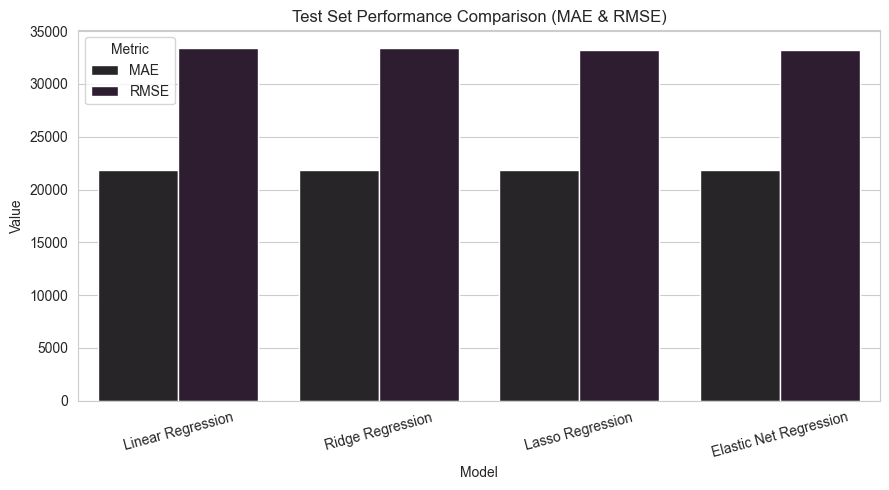

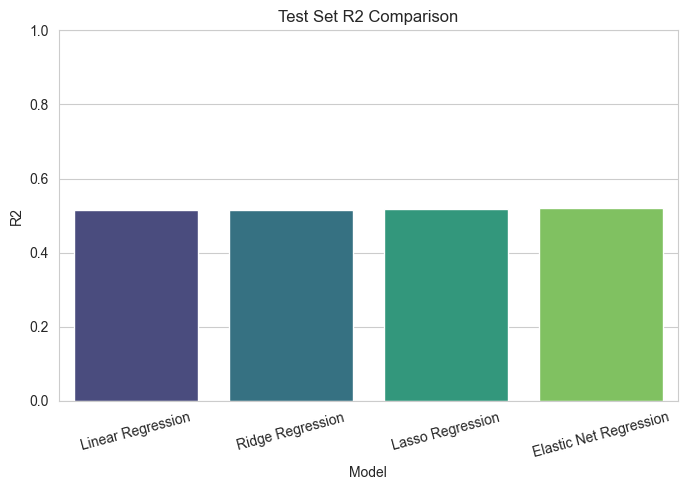

In [36]:
plt.figure(figsize=(9, 5))
metrics_to_plot = ["MAE", "RMSE"]
plot_df = test_table.melt(id_vars="Model", value_vars=metrics_to_plot, var_name="Metric", value_name="Value")
sns.barplot(data=plot_df, x="Model", y="Value", hue="Metric",color="#301934")
plt.title("Test Set Performance Comparison (MAE & RMSE)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.barplot(data=test_table, x="Model", y="R2", palette="viridis")
plt.title("Test Set R2 Comparison")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


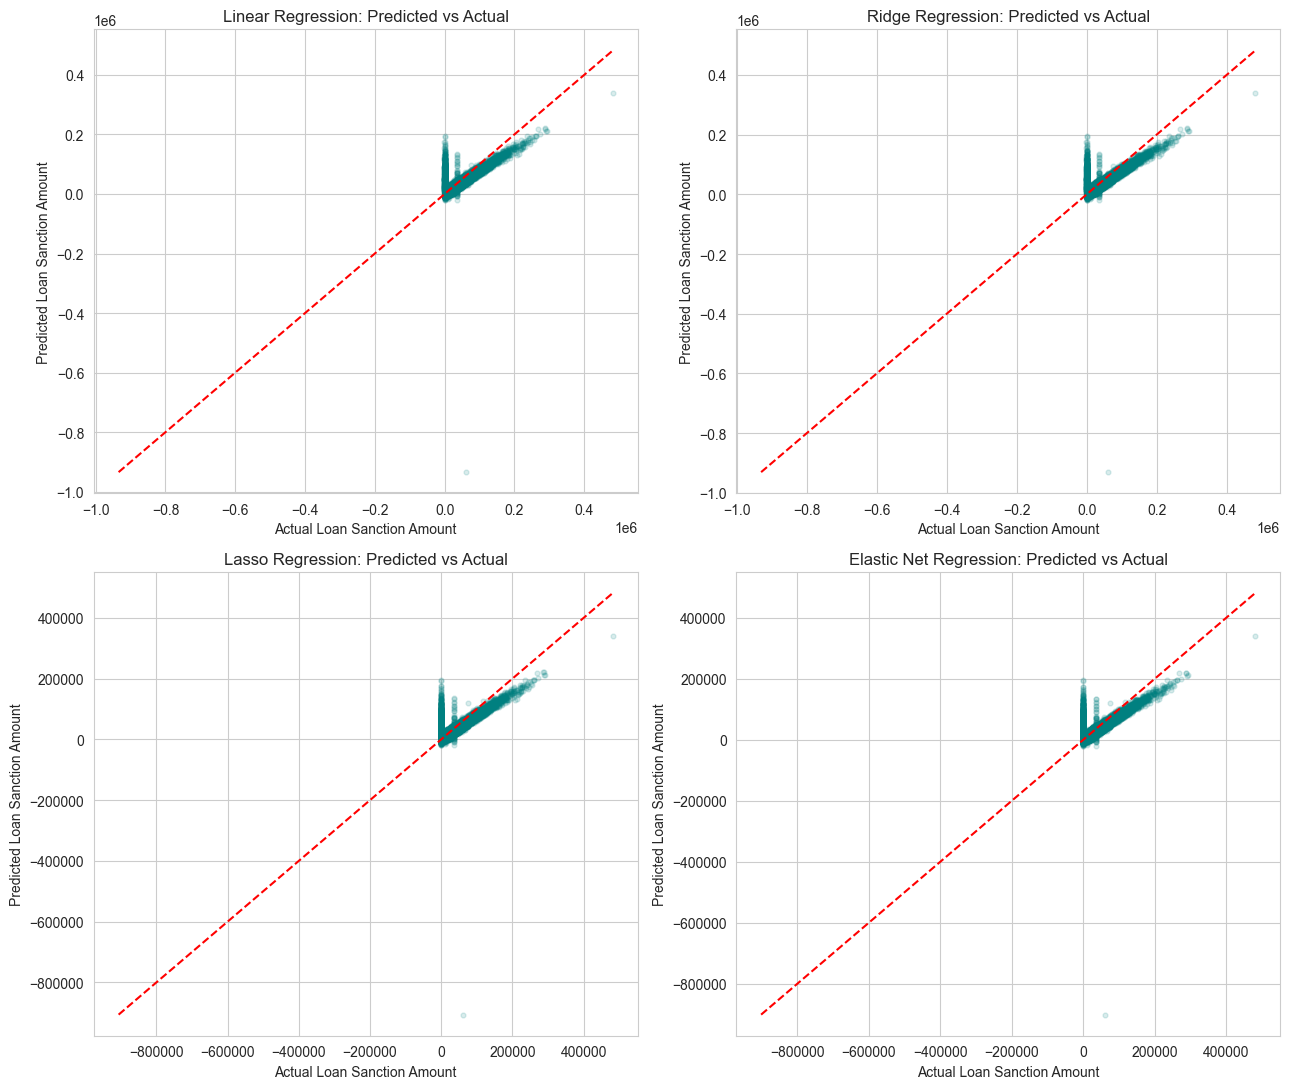

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.ravel()
model_names = ["Linear Regression", "Ridge Regression", "Lasso Regression", "Elastic Net Regression"]

for i, name in enumerate(model_names):
    y_pred = results[name]["y_test_pred"]
    axes[i].scatter(y_test, y_pred, alpha=0.15, s=12, color="#301934")
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    axes[i].plot(lims, lims, "r--", linewidth=1.5)
    axes[i].set_title(f"{name}: Predicted vs Actual")
    axes[i].set_xlabel("Actual Loan Sanction Amount")
    axes[i].set_ylabel("Predicted Loan Sanction Amount")

plt.tight_layout()
plt.show()


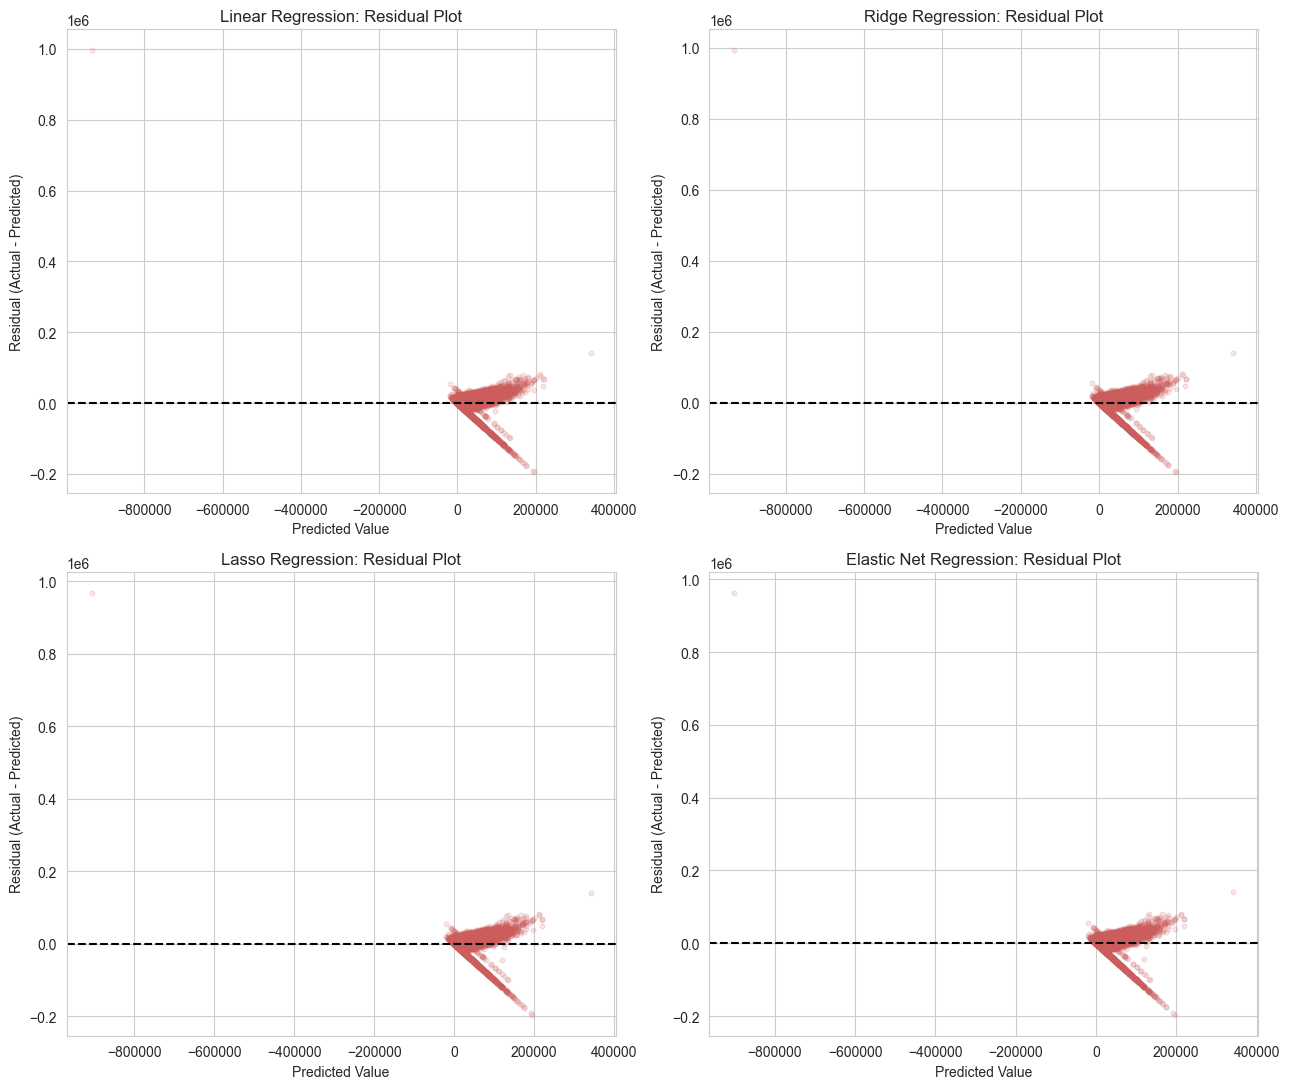

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.ravel()

for i, name in enumerate(model_names):
    y_pred = results[name]["y_test_pred"]
    residuals = y_test.values - y_pred
    axes[i].scatter(y_pred, residuals, alpha=0.15, s=12, color="#301934")
    axes[i].axhline(0, color="black", linestyle="--", linewidth=1.5)
    axes[i].set_title(f"{name}: Residual Plot")
    axes[i].set_xlabel("Predicted Value")
    axes[i].set_ylabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()


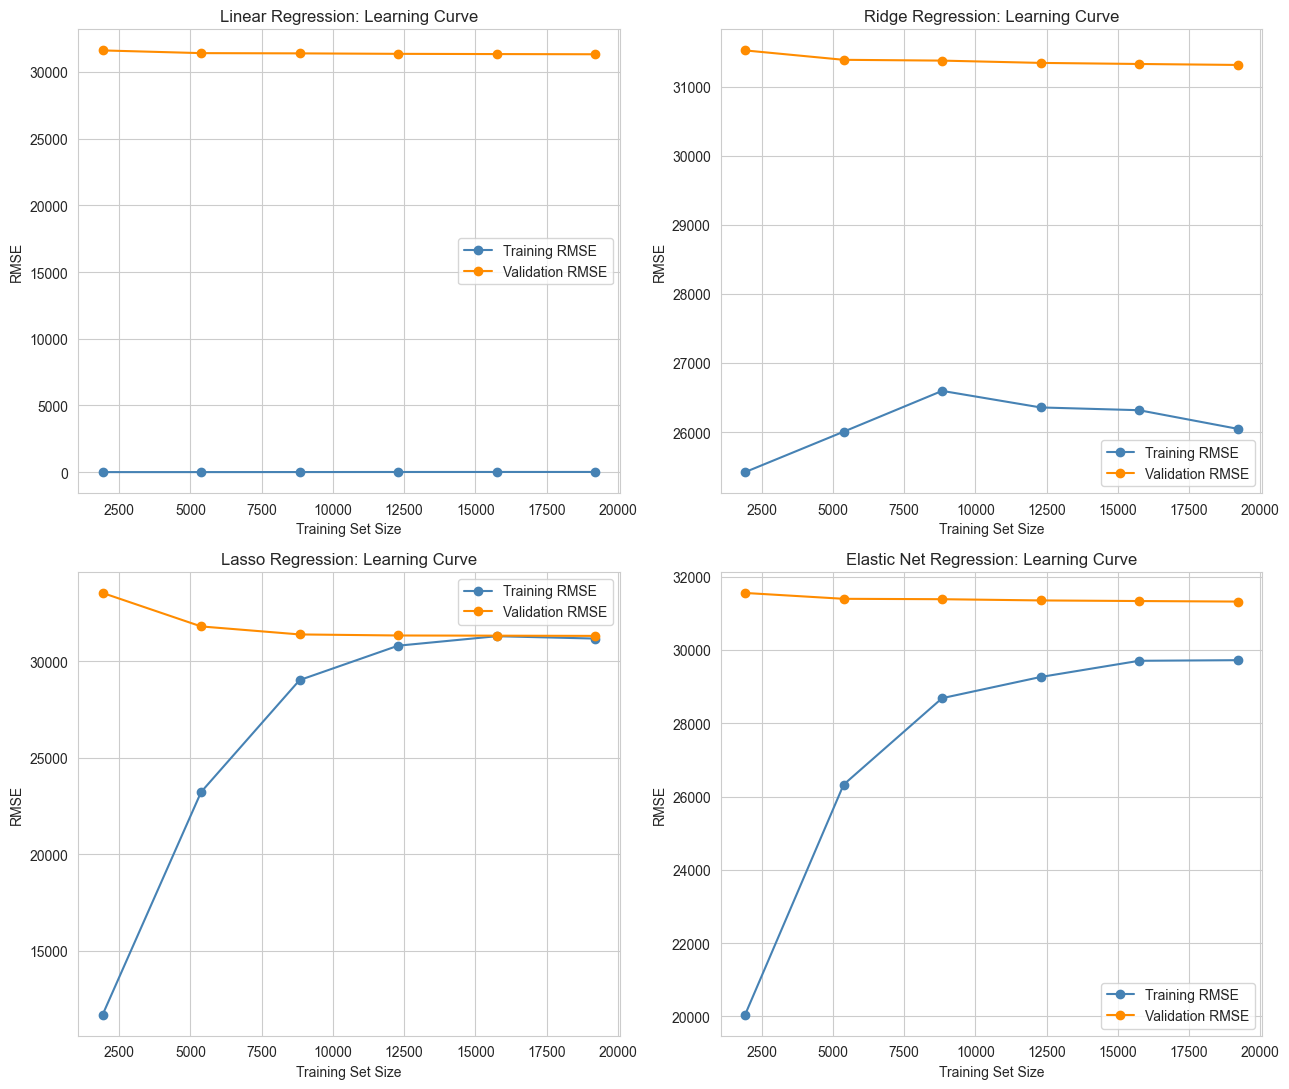

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.ravel()

for i, name in enumerate(model_names):
    model = fitted_models[name]
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train, cv=cv,
        scoring="neg_root_mean_squared_error",
        train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1
    )
    train_rmse = -train_scores.mean(axis=1)
    val_rmse = -val_scores.mean(axis=1)

    axes[i].plot(train_sizes, train_rmse, "o-", label="Training RMSE", color="#301934")
    axes[i].plot(train_sizes, val_rmse, "o-", label="Validation RMSE", color="indianred")
    axes[i].set_title(f"{name}: Learning Curve")
    axes[i].set_xlabel("Training Set Size")
    axes[i].set_ylabel("RMSE")
    axes[i].legend()

plt.tight_layout()
plt.show()


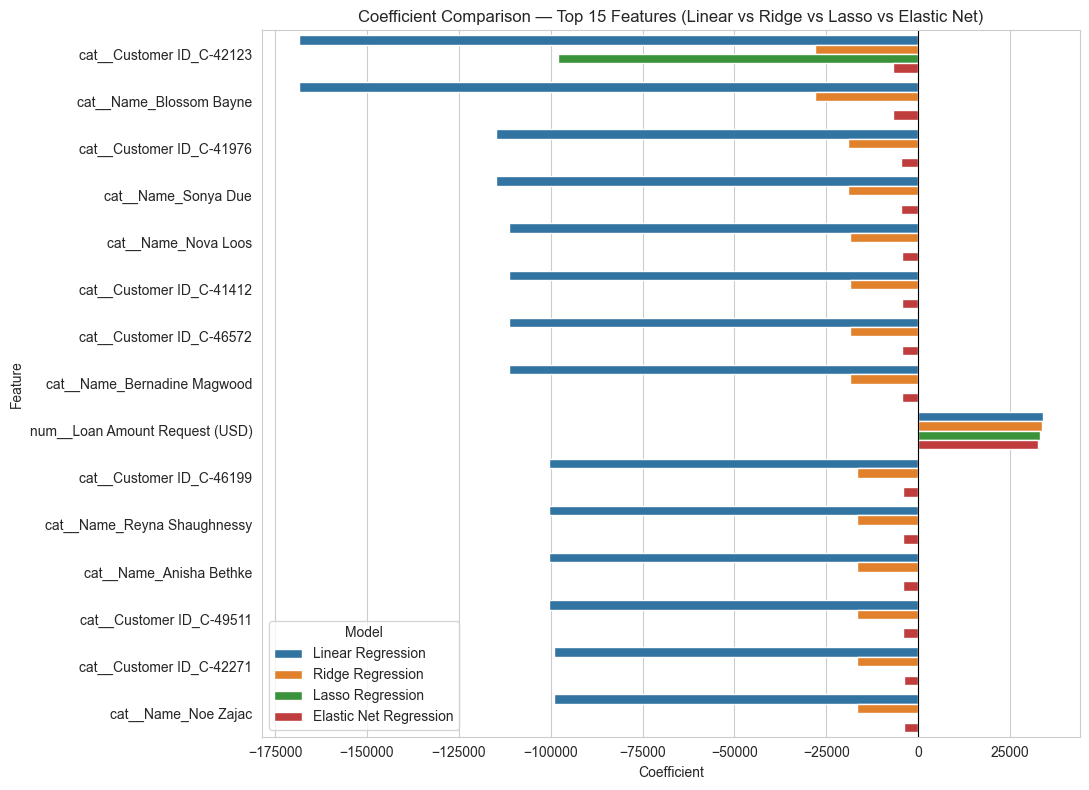

In [ ]:
feature_names = fitted_models["Linear Regression"].named_steps["preprocessor"].get_feature_names_out()

coef_dict = {}
for name in model_names:
    coef_dict[name] = fitted_models[name].named_steps["regressor"].coef_

coef_df = pd.DataFrame(coef_dict, index=feature_names)
coef_df["avg_abs"] = coef_df[model_names].abs().mean(axis=1)
top_features = coef_df.sort_values("avg_abs", ascending=False).head(15).drop(columns="avg_abs")

top_features_plot = top_features.reset_index().melt(id_vars="index", var_name="Model", value_name="Coefficient")
top_features_plot = top_features_plot.rename(columns={"index": "Feature"})

plt.figure(figsize=(11, 8))
sns.barplot(data=top_features_plot, y="Feature", x="Coefficient", hue="Model")
plt.title("Coefficient Comparison — Top 15 Features (Linear vs Ridge vs Lasso vs Elastic Net)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


In [ ]:
top_features.round(3)


,Linear Regression,Ridge Regression,Lasso Regression,Elastic Net Regression
cat__Customer ID_C-42123,-168480.050,-28086.706,-97942.720,-6745.634
cat__Name_Blossom Bayne,-168480.050,-28086.706,-0.000,-6745.656
cat__Customer ID_C-41976,-114767.388,-19104.316,-0.000,-4537.935
cat__Name_Sonya Due,-114767.388,-19104.316,-0.000,-4537.876
cat__Name_Nova Loos,-111447.189,-18587.634,-0.000,-4478.544
cat__Customer ID_C-41412,-111447.189,-18587.634,-0.000,-4478.508
cat__Customer ID_C-46572,-111344.454,-18553.500,-0.000,-4437.766
cat__Name_Bernadine Magwood,-111344.454,-18553.500,-0.000,-4437.756
num__Loan Amount Request (USD),33923.605,33768.282,33087.924,32691.699
cat__Customer ID_C-46199,-100565.711,-16757.426,-0.000,-4010.859


In [ ]:
n_zero_lasso = (coef_df["Lasso Regression"] == 0).sum()
n_zero_elastic = (coef_df["Elastic Net Regression"] == 0).sum()
n_total_features = coef_df.shape[0]

print(f"Total engineered features (after one-hot encoding): {n_total_features}")
print(f"Lasso zeroed out       : {n_zero_lasso} features ({100*n_zero_lasso/n_total_features:.1f}%)")
print(f"Elastic Net zeroed out : {n_zero_elastic} features ({100*n_zero_elastic/n_total_features:.1f}%)")
print(f"Ridge zeroed out       : {(coef_df['Ridge Regression']==0).sum()} features (Ridge basically never zeroes out coefficients)")


Total engineered features (after one-hot encoding): 48054
Lasso zeroed out       : 48019 features (99.9%)
Elastic Net zeroed out : 278 features (0.6%)
Ridge zeroed out       : 0 features (Ridge basically never zeroes out coefficients)


In [ ]:
gap_rows = []
for name in model_names:
    tr_r2 = results[name]["train"]["R2"]
    te_r2 = results[name]["test"]["R2"]
    gap_rows.append({"Model": name, "Train R2": tr_r2, "Test R2": te_r2, "Gap (Train - Test)": tr_r2 - te_r2})

gap_table = pd.DataFrame(gap_rows).round(4)
gap_table


,Model,Train R2,Test R2,Gap (Train - Test)
0,Linear Regression,1.0000,0.5150,0.4850
1,Ridge Regression,0.7050,0.5155,0.1895
2,Lasso Regression,0.5760,0.5191,0.0568
3,Elastic Net Regression,0.6082,0.5196,0.0886


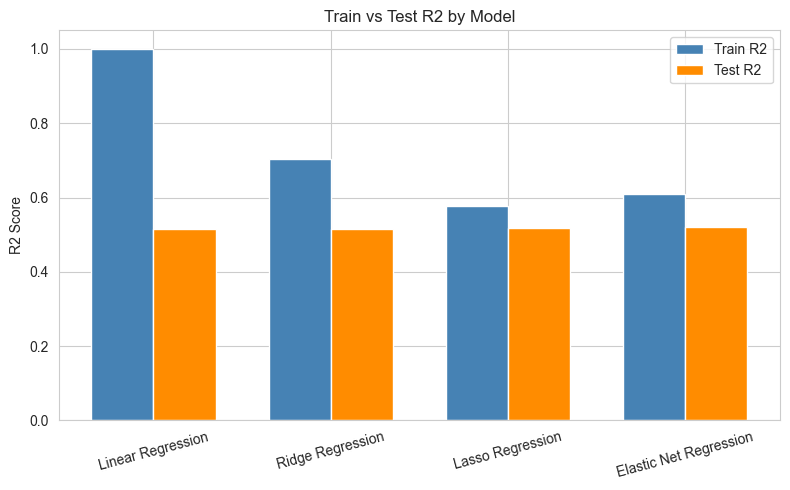

In [ ]:
plt.figure(figsize=(8, 5))
x = np.arange(len(gap_table))
width = 0.35
plt.bar(x - width/2, gap_table["Train R2"], width, label="Train R2", color="#301934")
plt.bar(x + width/2, gap_table["Test R2"], width, label="Test R2", color="indianred")
plt.xticks(x, gap_table["Model"], rotation=15)
plt.ylabel("R2 Score")
plt.title("Train vs Test R2 by Model")
plt.legend()
plt.tight_layout()
plt.show()
